# IN5437 — Assignment 1
## Question 10: Bilateral Filtering

**Name:** Benjamine  
**Index:** 258762A

- (a) Write a function to manually implement a bilateral filter.
- (b) Apply Gaussian smoothing using `cv.GaussianBlur()`.
- (c) Apply bilateral filtering using `cv.bilateralFilter()`.
- (d) Apply my manual bilateral filter from (a).

Bilateral filter weights each neighbor by two factors:
- **Spatial Gaussian** — how close the neighbor is (σₛ)
- **Range Gaussian** — how similar its intensity is (σᵣ)

This smooths uniform regions while preserving edges.

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 10.a: Manual bilateral filter function

For each pixel, look at its neighbors, compute a weight based on spatial distance AND intensity difference, then take the weighted average.

In [17]:
def bilateral_filter_manual(image, diameter, sigma_s, sigma_r):
    """Bilateral filter for grayscale images."""
    image = image.astype(np.float64)
    h, w = image.shape
    radius = diameter // 2
    out = np.zeros_like(image)

    # Loop through every pixel in the image
    for i in range(h):
        for j in range(w):
            weighted_sum = 0.0
            weight_total = 0.0

            # Look at each neighbor within the kernel
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    ni = i + di
                    nj = j + dj

                    # Skip if neighbor is outside the image
                    if ni < 0 or ni >= h or nj < 0 or nj >= w:
                        continue

                    # Spatial weight (based on distance from center)
                    spatial = np.exp(-(di**2 + dj**2) / (2 * sigma_s**2))

                    # Range weight (based on intensity difference)
                    intensity_diff = image[ni, nj] - image[i, j]
                    range_w = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))

                    # Combined weight
                    weight = spatial * range_w

                    # Accumulate
                    weighted_sum += weight * image[ni, nj]
                    weight_total += weight

            # Normalize
            out[i, j] = weighted_sum / weight_total

    return np.clip(out, 0, 255).astype(np.uint8)

### Load the image

Since our manual function is slow (nested Python loops), we resize the image to around 200×200 pixels so it runs in a reasonable time.

Original shape: (841, 561)
Resized shape:  (200, 133)


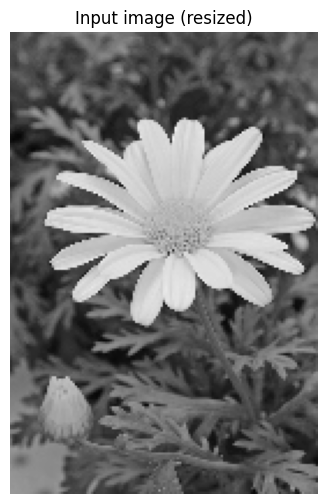

In [18]:
q10_im_full = cv.imread('../images/daisy.jpg', cv.IMREAD_GRAYSCALE)
assert q10_im_full is not None, "File could not be read. Check the path."

# Resize to 200 px so the manual filter runs in reasonable time
scale = 200 / max(q10_im_full.shape)
q10_im = cv.resize(q10_im_full, None, fx=scale, fy=scale)

print(f'Original shape: {q10_im_full.shape}')
print(f'Resized shape:  {q10_im.shape}')

plt.figure(figsize=(6, 6))
plt.imshow(q10_im, cmap='gray', vmin=0, vmax=255)
plt.title('Input image (resized)')
plt.axis('off')
plt.show()

### Question 10.b: Gaussian smoothing with `cv.GaussianBlur()`

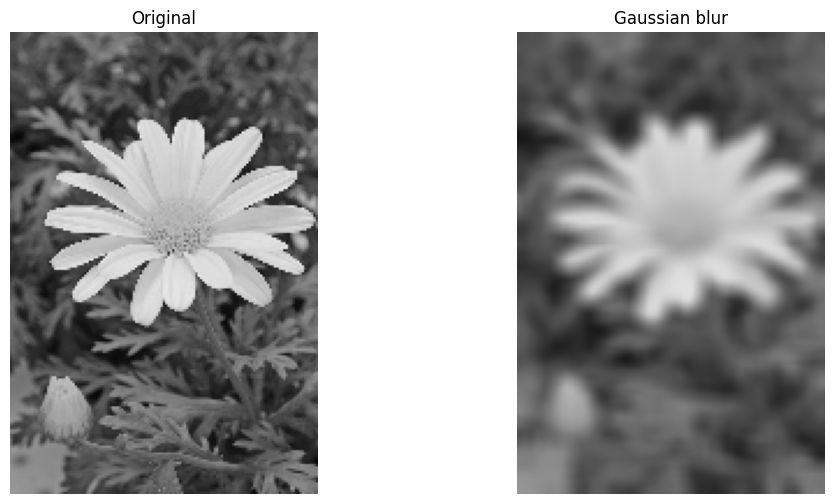

In [19]:
g_10b = cv.GaussianBlur(q10_im, (9, 9), 5)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(q10_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(g_10b,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Gaussian blur'); ax[1].axis('off')
plt.show()

### Question 10.c: Bilateral filter with `cv.bilateralFilter()`

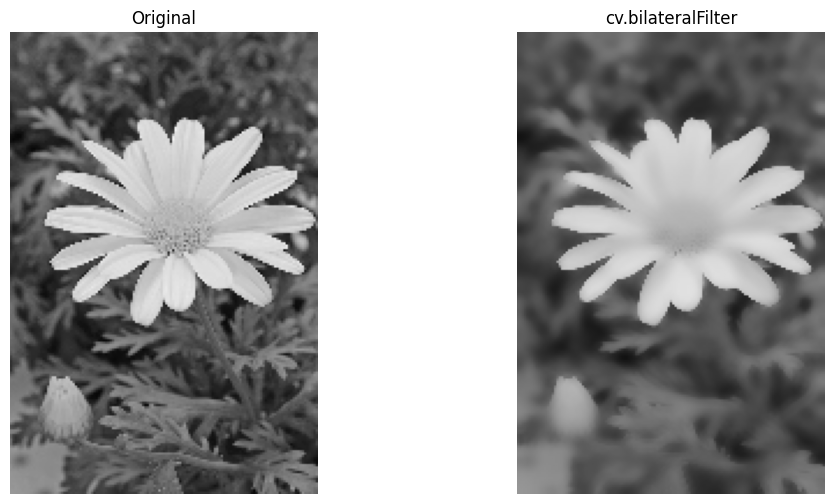

In [20]:
g_10c = cv.bilateralFilter(q10_im, d=9, sigmaColor=75, sigmaSpace=75)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(q10_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(g_10c,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('cv.bilateralFilter'); ax[1].axis('off')
plt.show()

### Question 10.d: My manual bilateral filter

Apply the function from (a) with the same parameters. Expect 30–60 seconds runtime.

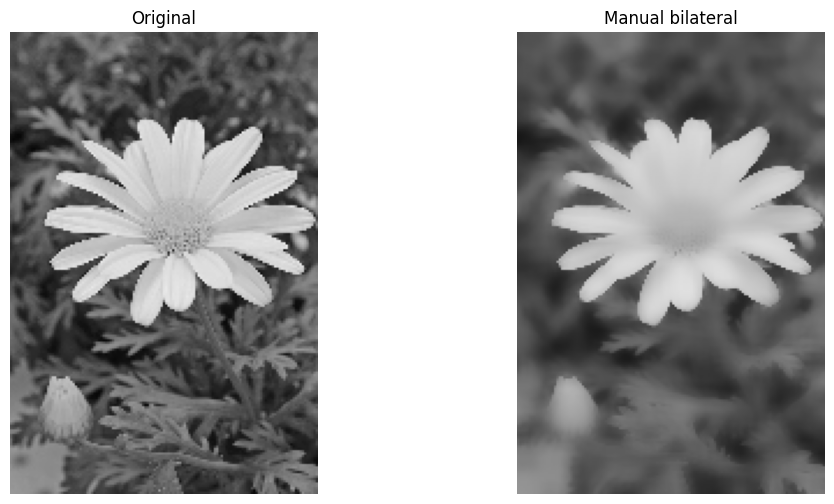

In [21]:
g_10d = bilateral_filter_manual(q10_im, diameter=9, sigma_s=75, sigma_r=75)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(q10_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(g_10d,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Manual bilateral'); ax[1].axis('off')
plt.show()

### Comparison: all four images

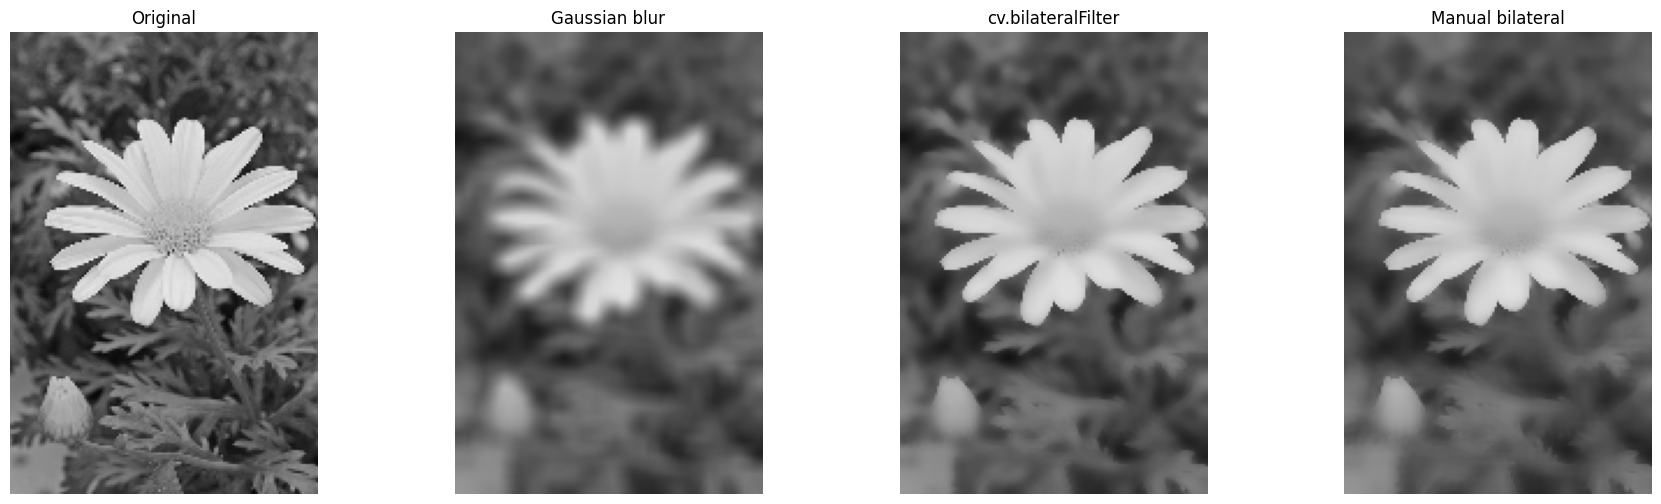

In [22]:
fig, ax = plt.subplots(1, 4, figsize=(22, 6))
ax[0].imshow(q10_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original');             ax[0].axis('off')
ax[1].imshow(g_10b,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Gaussian blur');        ax[1].axis('off')
ax[2].imshow(g_10c,  cmap='gray', vmin=0, vmax=255); ax[2].set_title('cv.bilateralFilter');   ax[2].axis('off')
ax[3].imshow(g_10d,  cmap='gray', vmin=0, vmax=255); ax[3].set_title('Manual bilateral');     ax[3].axis('off')
plt.show()

### Observation

**Gaussian blur vs bilateral filter.** Gaussian blur smooths the image uniformly — smooth areas (the background) and edges (petal boundaries) are all softened equally, so the image looks generally blurred. The bilateral filter smooths only within regions of similar intensity and preserves edges. On the daisy, the smooth petal surfaces are softened, but the sharp boundary between petals and background stays crisp. This is because pixels on the opposite side of an edge have very different intensities, so their range-Gaussian weight is nearly zero and they contribute almost nothing to the output.

**My implementation vs OpenCV.** My manual bilateral filter produces a result visually very similar to `cv.bilateralFilter()`. Small numerical differences come from OpenCV's internal optimizations (integer arithmetic, precomputed lookup tables, different edge-handling), but the visual result is essentially identical — confirming my implementation is correct.

**Speed.** My manual function uses four nested Python loops and took approximately 30–60 seconds on a 200×200 image. OpenCV's version runs in milliseconds because it is implemented in optimized C++. This is why bilateral filtering is always done with `cv.bilateralFilter()` in practice — the algorithm is inherently `O(N × D²)` (N pixels, D²-size kernel) which scales poorly when written in plain Python.

**Parameters.** Using σₛ = 75 (spatial) and σᵣ = 75 (range) with a 9×9 kernel gave a balanced result. Smaller σᵣ preserves more detail but smooths less; larger σᵣ makes the bilateral filter behave more like a plain Gaussian blur because the range weight stops distinguishing between similar and different intensities.